In [190]:
import xarray
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

In [192]:
val_ds = xarray.open_zarr("../cached-data/era5_2p8_2016_3l.zarr")  #era5_2p8_1996_2015_3l_clim.zarr")

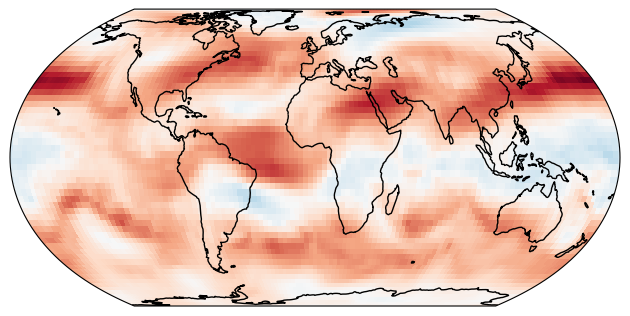

In [208]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.EqualEarth()}, dpi=100)

var = "U150"
val_ds[var].isel(time=0).plot(ax=ax, transform=ccrs.PlateCarree(), add_colorbar=False, add_labels=False)
ax.coastlines()
plt.tight_layout()
plt.savefig(f"{var}.png", transparent=True)

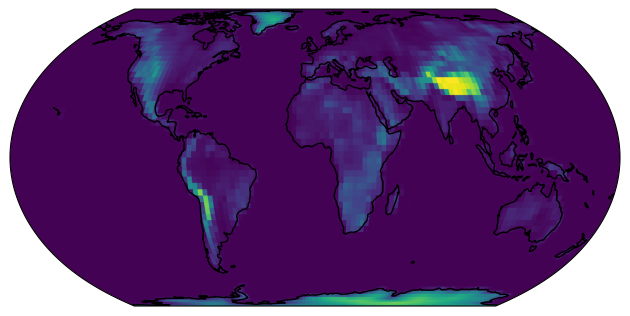

In [229]:
import numpy as np
static_features = np.load("../cached-data/era5_2p8_static.npz")

keys = ("latlon", "land_sea_mask", "geopotential_at_surface")
idx = 2
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.EqualEarth()}, dpi=100)
ax.imshow(static_features[keys[idx]][::-1, :], transform=ccrs.PlateCarree(), cmap="viridis")
ax.coastlines()
plt.tight_layout()
plt.savefig(f"oro.png", transparent=True)

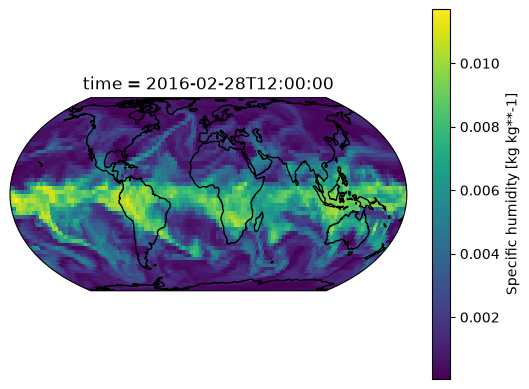

In [3]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.EqualEarth()}, dpi=100)

#clim[["U400", "V400"]].sel(hour=12, dayofyear=122).plot.streamplot(x="longitude", y="latitude", u="U400", v="V400", ax=ax, transform=ccrs.PlateCarree(), broken_streamlines=False, linewidth=0.5)
clim["Q700"].isel(time=234).plot(ax=ax, transform=ccrs.PlateCarree())
ax.coastlines()

In [4]:
q700 = clim["Q700"].isel(time=123).data.compute()

q = (q700 - q700.mean()) / q700.std()

np.float32(0.011910002)

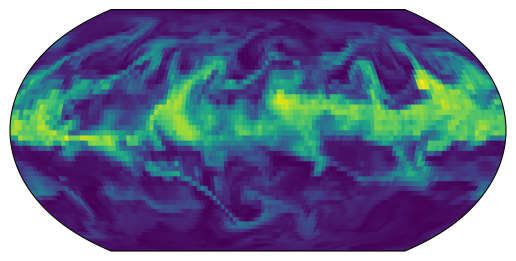

In [5]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.EqualEarth()}, dpi=100)
ax.imshow(q, transform=ccrs.PlateCarree())

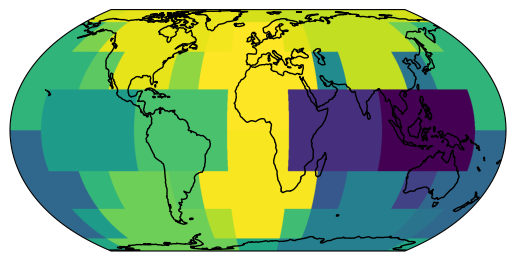

In [105]:
from wf.modules.gnn import GridGraphConv
import torch

gc = GridGraphConv(
        1,
        8,
        16,
        2,
        mesh_level=0,
        edge_embed=3,
        node_embed=3,
        ffn_factor=2,
        activation=torch.nn.Tanh,
    )

#x = torch.tensor(q).view(1, -1, 1)
x = torch.ones(1, 8*16, 1)
y = gc(x).detach().cpu()
y = y.view(8, 16).numpy()

fig, ax = plt.subplots(subplot_kw={"projection": ccrs.EqualEarth()}, dpi=100)
ax.imshow(y, transform=ccrs.PlateCarree())
ax.coastlines()

In [107]:
import xarray as xr
import numpy as np
import math

def compute_cell_areas(ds: xr.Dataset):
    lat = ds["latitude"].data
    lon = ds["longitude"].data
    lat_angle_rad = np.diff(lat)[0].item() * (math.pi / 180.0)
    lon_angle_rad = np.diff(lon)[0].item() * (math.pi / 180.0)
    lat = lat * (math.pi / 180.0)
    R = 6371.0  # earth mean radius
    return R**2 * lon_angle_rad * np.abs(np.sin(lat + (lat_angle_rad / 2.0)) - np.sin(lat - (lat_angle_rad / 2.0)))

(compute_cell_areas(clim) * 128).sum()

np.float64(510064471.9098009)

In [4]:
big = xr.open_zarr("gs://weatherbench2/datasets/era5/1959-2023_01_10-6h-240x121_equiangular_with_poles_conservative.zarr", storage_options={"token": "anon"}, chunks={})

In [25]:
(compute_cell_areas(big) * 240).sum()


np.float64(510020773.4490814)

In [16]:
lats = big.latitude.data

In [16]:
np.cos(np.abs(clim.latitude.data)*(math.pi / 180.0)) / np.mean(np.cos(np.abs(clim.latitude.data)*(math.pi / 180.0)))

array([0.0385454 , 0.11554335, 0.19226293, 0.26851935, 0.34412887,
       0.41890936, 0.49268066, 0.56526505, 0.63648766, 0.70617692,
       0.77416494, 0.84028793, 0.90438659, 0.9663065 , 1.0258985 ,
       1.08301901, 1.13753044, 1.18930146, 1.23820735, 1.28413029,
       1.32695964, 1.36659224, 1.40293259, 1.43589315, 1.46539453,
       1.49136564, 1.51374392, 1.53247545, 1.54751512, 1.55882669,
       1.56638291, 1.57016558, 1.57016558, 1.56638291, 1.55882669,
       1.54751512, 1.53247545, 1.51374392, 1.49136564, 1.46539453,
       1.43589315, 1.40293259, 1.36659224, 1.32695964, 1.28413029,
       1.23820735, 1.18930146, 1.13753044, 1.08301901, 1.0258985 ,
       0.9663065 , 0.90438659, 0.84028793, 0.77416494, 0.70617692,
       0.63648766, 0.56526505, 0.49268066, 0.41890936, 0.34412887,
       0.26851935, 0.19226293, 0.11554335, 0.0385454 ])

In [11]:
areas = compute_cell_areas(clim)


areas / areas.mean()

array([0.0385454 , 0.11554335, 0.19226293, 0.26851935, 0.34412887,
       0.41890936, 0.49268066, 0.56526505, 0.63648766, 0.70617692,
       0.77416494, 0.84028793, 0.90438659, 0.9663065 , 1.0258985 ,
       1.08301901, 1.13753044, 1.18930146, 1.23820735, 1.28413029,
       1.32695964, 1.36659224, 1.40293259, 1.43589315, 1.46539453,
       1.49136564, 1.51374392, 1.53247545, 1.54751512, 1.55882669,
       1.56638291, 1.57016558, 1.57016558, 1.56638291, 1.55882669,
       1.54751512, 1.53247545, 1.51374392, 1.49136564, 1.46539453,
       1.43589315, 1.40293259, 1.36659224, 1.32695964, 1.28413029,
       1.23820735, 1.18930146, 1.13753044, 1.08301901, 1.0258985 ,
       0.9663065 , 0.90438659, 0.84028793, 0.77416494, 0.70617692,
       0.63648766, 0.56526505, 0.49268066, 0.41890936, 0.34412887,
       0.26851935, 0.19226293, 0.11554335, 0.0385454 ])

In [36]:
np.abs(np.cos(clim.latitude.data * (math.pi / 180.0)) / np.cos(180 * (math.pi / 180.0))).sum()

np.float64(40.74775633446286)

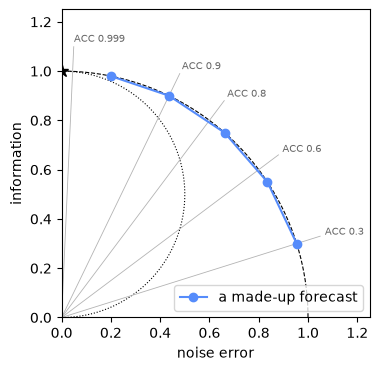

In [108]:
import matplotlib.pyplot as plt

def information_noise_diagram(ax, noise_error, information, true_activity, label=None, **plot_kwargs):
    '''Information, noise, and correlation diagram after Bonavita and Geer (2026), Figure 3.

    A forecast is a point at (noise error, information).
    Its distance from the origin is the forecast activity, the angle to the vertical axis
    has cosine equal to the anomaly correlation, and its distance to the point (0, true_activity)
    is the error.  The dashed quarter circle is the locus of forecasts with the true activity;
    the dashed half circle is the locus of lowest error for a given correlation.
    '''
    a = float(true_activity)
    theta = np.linspace(0, np.pi / 2, 200)
    ax.plot(a * np.sin(theta), a * np.cos(theta), "k--", lw=0.8)                       # forecast activity == true activity
    ax.plot(a / 2 * np.sin(2 * theta), a / 2 + a / 2 * np.cos(2 * theta), "k:", lw=0.8)  # lowest error for a given correlation
    for acc in (0.999, 0.9, 0.8, 0.6, 0.3):
        ang = np.arccos(acc)
        ax.plot([0, 1.1 * a * np.sin(ang)], [0, 1.1 * a * np.cos(ang)], color="0.7", lw=0.6)
        ax.annotate(f"ACC {acc}", (1.12 * a * np.sin(ang), 1.12 * a * np.cos(ang)), fontsize=7, color="0.4")
    ax.plot(0, a, "k*", ms=9)                                                          # the perfect forecast
    ax.plot(noise_error, information, "o-", label=label, **plot_kwargs)
    ax.set_aspect("equal")
    ax.set_xlim(0, 1.25 * a)
    ax.set_ylim(0, 1.25 * a)
    ax.set_xlabel("noise error")
    ax.set_ylabel("information")
    return ax


# a demonstration with made-up numbers: a forecast that loses correlation with lead time
fig, ax = plt.subplots(figsize=(4, 4))
acc = np.array([0.98, 0.9, 0.75, 0.55, 0.3])
a_f, a_t = 1.0, 1.0
information_noise_diagram(ax, a_f * np.sqrt(1 - acc**2), a_f * acc, a_t, label="a made-up forecast")
ax.legend(loc="lower right")
plt.show()

In [161]:
import numpy as np

metrics = np.load("../logs/WeT_afno_step4ft_metrics.npz")
ACC = metrics["ACC"]
RMSE = metrics["RMSE"]
A_pred = metrics["A_pred"]
A_true = metrics["A_true"]

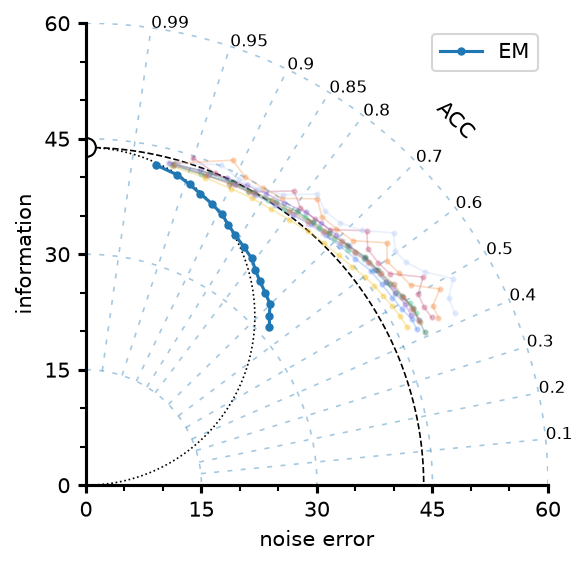

In [182]:
p = A_pred * ACC
IE = np.abs(A_true - p)
NE = np.sqrt((RMSE ** 2) - (IE ** 2))

var = 1


from matplotlib.ticker import MaxNLocator


def information_noise_diagram(ax, noise_error, information, true_activity, label=None, **plot_kwargs):
    '''Information, noise, and correlation diagram after Bonavita and Geer (2026), Figure 3.

    A forecast is a point at (noise error, information).
    Its distance from the origin is the forecast activity, the angle to the vertical axis
    has cosine equal to the anomaly correlation, and its distance to the point (0, true_activity)
    is the error.  The dashed quarter circle is the locus of forecasts with the true activity;
    the dashed half circle is the locus of lowest error for a given correlation.
    '''
    a = float(true_activity)

    # setup ticks
    minor_tick_bins = 3
    tick_locator = MaxNLocator(nbins=5)
    ticks = tick_locator.tick_values(0, 1.25 * a)
    mticks = np.linspace(ticks[0], ticks[-1], (len(ticks) * minor_tick_bins) - (minor_tick_bins - 1))
    tick_max = ticks[-1]

    # plot grid
    grid_color = "tab:blue"
    grid_linestyle = (0, (3, 5))
    grid_linewidth = 0.8
    grid_alpha = 0.4
    theta = np.linspace(0, np.pi / 2, 200)
    for grid_xy in ticks:
        ax.plot(grid_xy * np.sin(theta), grid_xy * np.cos(theta), linestyle=grid_linestyle, linewidth=grid_linewidth, c=grid_color, alpha=grid_alpha, zorder=-10)

    ax.plot(a * np.sin(theta), a * np.cos(theta), "k--", lw=0.8)                       # forecast activity == true activity
    ax.plot(a / 2 * np.sin(2 * theta), a / 2 + a / 2 * np.cos(2 * theta), "k:", lw=0.8)  # lowest error for a given correlation

    # plot ACC grid
    tick_font = ax.get_xticklabels()[0].get_fontproperties()
    for acc in (0.99, 0.95, 0.9, 0.85, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1):
        ang = np.arccos(acc)
        ax.plot([ticks[1] * np.sin(ang), tick_max * np.sin(ang)], [ticks[1] * np.cos(ang), tick_max * np.cos(ang)], c=grid_color, linestyle=grid_linestyle, linewidth=grid_linewidth, alpha=grid_alpha, zorder=-10)
        #ax.annotate(f"{acc}", (tick_max * np.sin(ang), tick_max * np.cos(ang)), fontproperties=tick_font, bbox=dict(boxstyle='square,pad=0', fc='none', ec='none'),)
        ax.text(tick_max * np.sin(ang), tick_max * np.cos(ang), f"{acc}", fontsize="small", bbox=None)
    ax.annotate(f"ACC", (0.75, 0.75), xycoords="axes fraction", fontsize="medium", color="k", rotation=-45)

    ax.plot(0, a, "o", ms=9, c="k", mfc="w")                                                          # the perfect forecast
    #ax.plot(noise_error, information, "o-", label=label, **plot_kwargs)
    ax.set_aspect("equal")

    # format ticks & spines
    ax.set_xlim(0, 1.25 * a)
    ax.set_ylim(0, 1.25 * a)
    ax.set_xticks(ticks)
    ax.set_xticks(mticks, minor=True)
    ax.set_yticks(ticks)
    ax.set_yticks(mticks, minor=True)
    ax.spines.right.set_visible(False)
    ax.spines.top.set_visible(False)
    ax.spines.left.set(linewidth=1.5)
    ax.spines.bottom.set(linewidth=1.5)
    ax.tick_params(which='major', direction="out", width=1.5, length=4)
    ax.tick_params(which='minor', direction="out", width=1.0, length=3)

    ax.set_xlabel("noise error")
    ax.set_ylabel("information")
    return ax


fig, ax = plt.subplots(figsize=(4, 4), dpi=150)

information_noise_diagram(ax, None, None, A_true[var, 0].mean())
for i in range(1, p.shape[1]):
    ax.plot(NE[var, i], p[var, i], "o-", label=None, alpha=0.3, markersize=2, linewidth=0.8)

ax.plot(NE[var, 0], p[var, 0], "o-", label="EM", markersize=3, c="tab:blue")

ax.legend(loc="upper right")
plt.show()


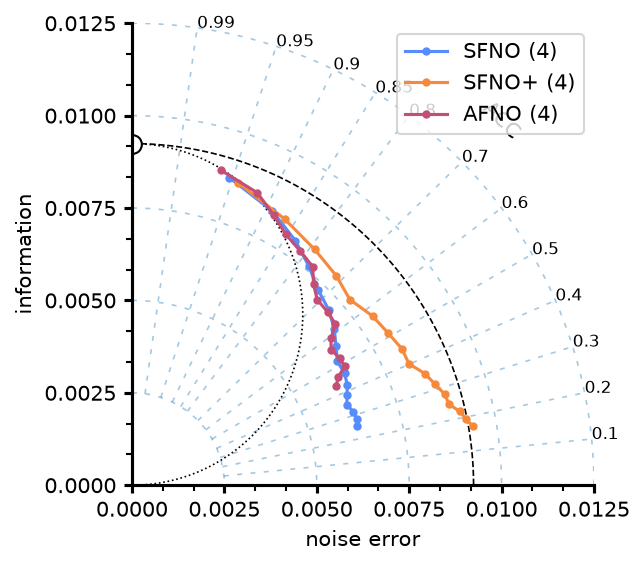

In [185]:
models = {
    #"SFNO": "../logs/WeT_sfno_base_metrics.npz",
    "SFNO (4)": "../logs/WeT_sfno_step4ft_metrics.npz",
    #"SFNO+": "../logs/WeT_sfno_gcn_base_metrics.npz",
    "SFNO+ (4)": "../logs/WeT_sfno_gcn_step4ft_metrics.npz",
    #"AFNO": "../logs/WeT_afno_base_metrics.npz",
    "AFNO (4)": "../logs/WeT_afno_step4ft_metrics.npz",
}

var = 10

fig, ax = plt.subplots(figsize=(4, 4), dpi=150)
information_noise_diagram(ax, None, None, A_true[var, 0].mean())

for model_name, metrics_path in models.items():
    metrics = np.load(metrics_path)
    ACC = metrics["ACC"]
    RMSE = metrics["RMSE"]
    A_pred = metrics["A_pred"]
    A_true = metrics["A_true"]

    p = A_pred * ACC
    IE = np.abs(A_true - p)
    NE = np.sqrt((RMSE ** 2) - (IE ** 2))

    ax.plot(NE[var, 0], p[var, 0], "o-", label=model_name, markersize=3)

ax.legend(loc="upper right")
plt.show()


In [189]:
A_true[0, 0].min(), A_true[0, 0].max()

(np.float64(34.74352020285102), np.float64(36.277782067523184))

In [164]:
time_rank_hist = metrics["rank_histogram"].sum(axis=0) / metrics["rank_histogram"].sum(axis=0).sum(axis=1).reshape(-1, 1)

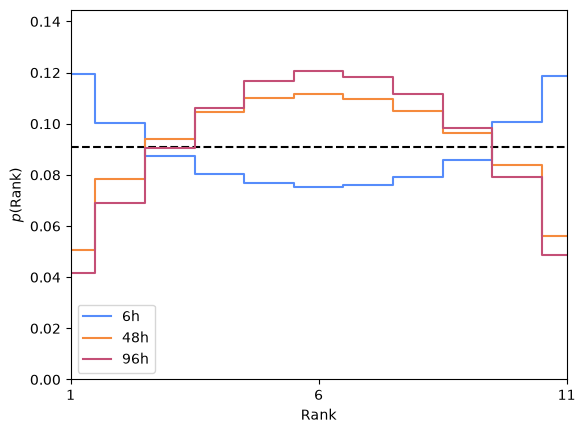

In [165]:
rank_histogram = time_rank_hist[15]

fig, ax = plt.subplots()
for hist_idx in (0, 7, 15):
    data = time_rank_hist[hist_idx]
    ax.step(np.arange(data.shape[0]), data, where="mid", label=f"{6 * (hist_idx+1)}h")
ax.set_ylim(0, rank_histogram.max() * 1.2)
ax.set_xlim(0, data.shape[0]-1)
ticks = np.arange(0, data.shape[0], step=5)
ax.set_xticks(ticks, labels=[str(int(t+1)) for t in ticks])
ax.axhline(1.0 / len(rank_histogram), color="k", linestyle="--", zorder=-10)
ax.set_xlabel("Rank")
ax.set_ylabel(r"$p\left( \text{Rank} \right)$")
ax.legend()
plt.show()

In [145]:
pred_hist = metrics["clim_pred_histogram"]
true_hist = metrics["clim_true_histogram"]


In [146]:
pred = pred_hist.sum(axis=(1, 2))

pred_hist.shape

(2, 19, 16, 11)

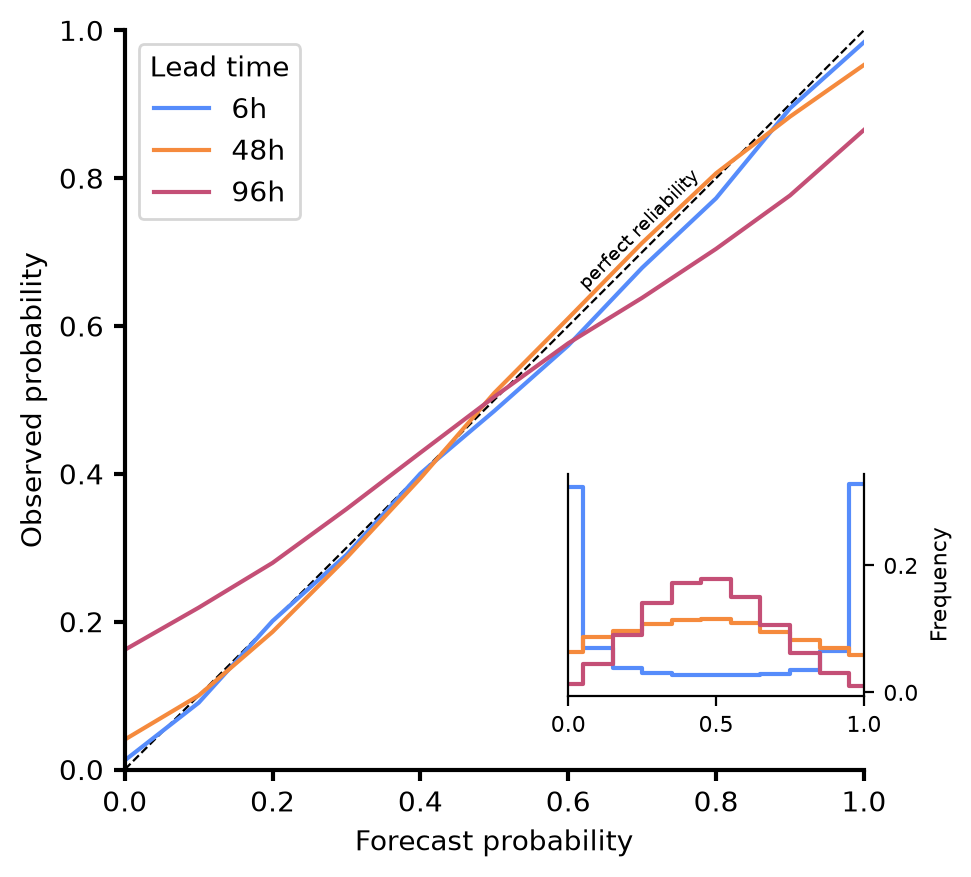

In [147]:
cls = 0
var = 1

n_bins = pred_hist.shape[-1]

forecast_prob = np.arange(0.0, n_bins, 1.0) / (n_bins - 1)

fig, ax = plt.subplots(dpi=200)
iax = ax.inset_axes(bounds=(0.6, 0.1, 0.4, 0.3))
iax.set_xlim(0, 1)
iax.set_ylabel("Frequency")
iax.spines.top.set_visible(False)
iax.yaxis.tick_right()
iax.yaxis.set_label_position("right")

ax.plot([0, 1], [0, 1], c="k", linestyle="--", linewidth=0.8)

for time_ix in (0, 7, 15):
    true = true_hist[var, time_ix, :, :, cls]
    observed_prob = (true / true.sum(axis=1).reshape(-1, 1))[:, cls]
    l = ax.plot(forecast_prob, observed_prob, lw=1.5, label=f"{(time_ix+1)*6}h")
    c = l[0].get_color()

    pred = pred_hist[cls, var, time_ix]
    pred = pred / pred.sum()
    iax.step(forecast_prob, pred, c=c, where="mid")

for item in ([iax.title, iax.xaxis.label, iax.yaxis.label] +
             iax.get_xticklabels() + iax.get_yticklabels()):
    item.set_fontsize(8)

ax.annotate(f"perfect reliability", (0.61, 0.65), xycoords="axes fraction", fontsize="x-small", color="k", rotation=45)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
ax.spines.left.set(linewidth=1.5)
ax.spines.bottom.set(linewidth=1.5)
ax.tick_params(which='major', direction="out", width=1.5, length=4)
ax.tick_params(which='minor', direction="out", width=1.0, length=3)

ax.set_xlabel("Forecast probability")
ax.set_ylabel("Observed probability")
ax.legend(title="Lead time")
plt.show()

In [515]:
import numpy as np
from einops import rearrange

latlon = rearrange(np.stack(np.meshgrid(clim["latitude"].data, clim["longitude"].data), axis=-1), "lon lat c -> lat lon c")

In [494]:
from wf.data.dataset import _convert_longitude_360_to_180

ds = xr.open_zarr("gs://weatherbench2/datasets/era5/1959-2022-6h-128x64_equiangular_conservative.zarr", storage_options={"token": "anon"}, chunks={})
ds = ds[["land_sea_mask", "geopotential_at_surface"]]
ds = _convert_longitude_360_to_180(ds, check=True)
ds.values()

ValuesView(<xarray.Dataset> Size: 67kB
Dimensions:                  (longitude: 128, latitude: 64)
Coordinates:
  * longitude                (longitude) float64 1kB -180.0 -177.2 ... 177.2
  * latitude                 (latitude) float64 512B -88.59 -85.78 ... 88.59
Data variables:
    land_sea_mask            (longitude, latitude) float32 33kB dask.array<chunksize=(128, 64), meta=np.ndarray>
    geopotential_at_surface  (longitude, latitude) float32 33kB dask.array<chunksize=(128, 64), meta=np.ndarray>)

In [495]:
lsm = ds["land_sea_mask"].data.compute()
gps = ds["geopotential_at_surface"].data.compute()

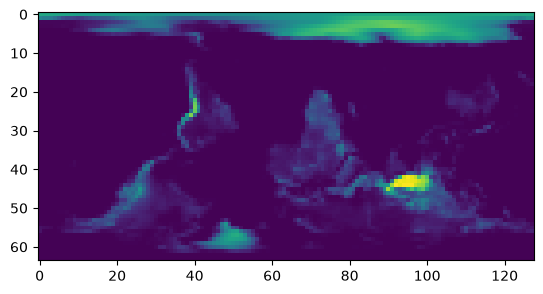

In [511]:
plt.imshow(gps.T)

C:\Users\voigt\AppData\Local\Temp\ipykernel_8288\3801799431.py:7: RuntimeWarning: invalid value encountered in log
  {"geo": xr.DataArray((np.log(gps.T) - np.log(gps).mean()) / np.log(gps).std(), dims=dims)},


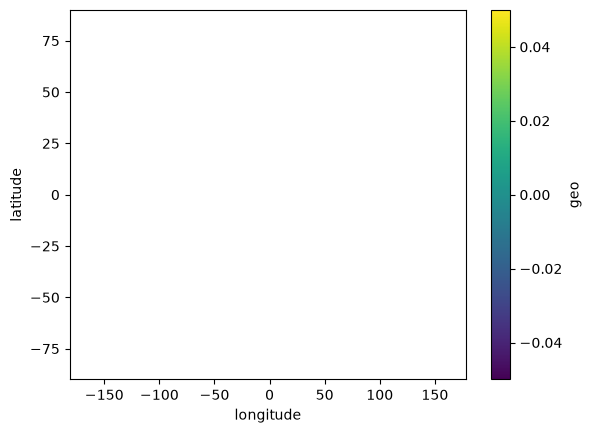

In [522]:
_coords = {
    "latitude": ds["latitude"].data,
    "longitude": ds["longitude"].data,
}
dims = ["latitude", "longitude"]
ds = xr.Dataset(
    {"geo": xr.DataArray((np.log(gps.T) - np.log(gps).mean()) / np.log(gps).std(), dims=dims)},
    coords=_coords,
)
ds["geo"].plot()

12.567632351660357
12.566370614359172


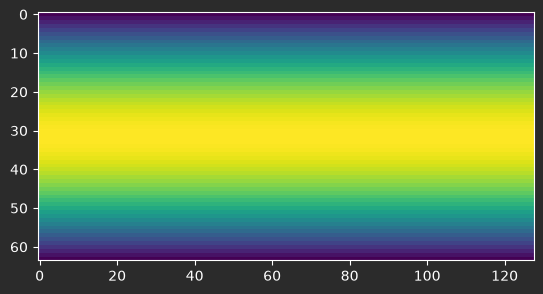

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from einops import rearrange

lat = clim["latitude"].data
lon = clim["longitude"].data
lat_grid = np.broadcast_to(lat.reshape(-1, 1), (len(lat), len(lon))) + 90.0
quad_weights = ((2.0 * (np.pi ** 2)) / (len(lat) * len(lon))) * np.sin(np.deg2rad(lat_grid))

print(quad_weights.sum())
print(np.pi * 4.0)

plt.imshow(quad_weights)


In [32]:
180.0 / 2.8125

64.0

In [34]:
(np.arange(64) * 2.8125) + (2.8125 / 2.0)

array([  1.40625,   4.21875,   7.03125,   9.84375,  12.65625,  15.46875,
        18.28125,  21.09375,  23.90625,  26.71875,  29.53125,  32.34375,
        35.15625,  37.96875,  40.78125,  43.59375,  46.40625,  49.21875,
        52.03125,  54.84375,  57.65625,  60.46875,  63.28125,  66.09375,
        68.90625,  71.71875,  74.53125,  77.34375,  80.15625,  82.96875,
        85.78125,  88.59375,  91.40625,  94.21875,  97.03125,  99.84375,
       102.65625, 105.46875, 108.28125, 111.09375, 113.90625, 116.71875,
       119.53125, 122.34375, 125.15625, 127.96875, 130.78125, 133.59375,
       136.40625, 139.21875, 142.03125, 144.84375, 147.65625, 150.46875,
       153.28125, 156.09375, 158.90625, 161.71875, 164.53125, 167.34375,
       170.15625, 172.96875, 175.78125, 178.59375])

In [35]:
lat + 90.0

array([  1.40625,   4.21875,   7.03125,   9.84375,  12.65625,  15.46875,
        18.28125,  21.09375,  23.90625,  26.71875,  29.53125,  32.34375,
        35.15625,  37.96875,  40.78125,  43.59375,  46.40625,  49.21875,
        52.03125,  54.84375,  57.65625,  60.46875,  63.28125,  66.09375,
        68.90625,  71.71875,  74.53125,  77.34375,  80.15625,  82.96875,
        85.78125,  88.59375,  91.40625,  94.21875,  97.03125,  99.84375,
       102.65625, 105.46875, 108.28125, 111.09375, 113.90625, 116.71875,
       119.53125, 122.34375, 125.15625, 127.96875, 130.78125, 133.59375,
       136.40625, 139.21875, 142.03125, 144.84375, 147.65625, 150.46875,
       153.28125, 156.09375, 158.90625, 161.71875, 164.53125, 167.34375,
       170.15625, 172.96875, 175.78125, 178.59375])